# 沐曦 GPU 运行 BiomedCLIP 说明文档

[BiomedCLIP-PubMedBERT_256-vit_base_patch16_224](https://huggingface.co/microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224) 是 Microsoft 发布的生物医学视觉语言基础模型。模型使用 PubMedBERT 文本编码器和 ViT-B/16 图像编码器，在 PMC-15M 图文对上进行对比学习，可用于医学图像分类、跨模态检索等研究任务。

本 Notebook 在 MACA GPU 上复现模型卡的 OpenCLIP 推理路径：对公开示例图像执行医学图像零样本分类，并执行一个独立的图文相似度检索任务。模型、输入身份、设备和输出目录都由同一组参数锚点驱动；Notebook 不调用外部脚本、不自动下载权重，也不改变上游模型语义。输出仅用于开源软件适配和研究/工程验证，不用于诊断、治疗或临床决策。

[BiomedCLIP](https://huggingface.co/microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224) 由 Microsoft 以 [MIT License](https://huggingface.co/microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224/blob/main/LICENSE.md) 发布，我方未对其源代码、模型权重或推理语义作任何修改。模型权重、PMC-15M 训练数据和模型卡示例图像仍应以各自上游页面的授权条款为准；本 Notebook 不包含模型权重和患者数据。

## 1. 安装

下面的命令只说明环境准备方式，不由 Notebook 自动执行。请使用包含 MACA 版 PyTorch 与 torchvision 的沐曦镜像；镜像版本和可用资源可从[沐曦开发者社区 Docker 镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取。启动容器时只挂载本目录，模型、权重和公开示例图像按后文步骤准备。运行时只需计算设备节点 `/dev/mxcd`。

```bash
docker run -it --name biomedclip-maca \
  --device=/dev/mxcd --group-add video \
  --shm-size=8G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /path/to/MedicalImage/vlm/BiomedCLIP:/workspace/tutorial \
  <MACA_PYTORCH_IMAGE> /bin/bash
```

在容器中安装 OpenCLIP、Transformers、Pillow、Matplotlib、Jupyter 和 Hugging Face Hub 命令行工具。下面的模型、权重和输入准备命令只用于说明安装过程；请在容器启动后、运行 Notebook 前完成这些准备。

```bash
python -m pip install open_clip_torch transformers pillow matplotlib jupyterlab huggingface_hub
```

### 1.2 准备 BiomedCLIP 模型与权重

`open_clip_pytorch_model.bin` 是 BiomedCLIP 的视觉语言 checkpoint；`open_clip_config.json`、`tokenizer.json`、`tokenizer_config.json`、`special_tokens_map.json` 和 `vocab.txt` 用于 OpenCLIP/PubMedBERT 文本侧构造。由于 checkpoint 已包含本模型使用的文本编码器参数，本 Notebook 的本地加载路径不需要另行下载 PubMedBERT 的 `pytorch_model.bin`，但需要从 `microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract` 补齐文本模型 `config.json`。

```bash
MODEL_DIR=/workspace/assets/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
mkdir -p "$MODEL_DIR"
hf download microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224 \
  open_clip_pytorch_model.bin open_clip_config.json \
  tokenizer.json tokenizer_config.json special_tokens_map.json vocab.txt \
  --local-dir "$MODEL_DIR"
hf download microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract \
  config.json --local-dir "$MODEL_DIR"

for file in open_clip_pytorch_model.bin open_clip_config.json config.json tokenizer.json tokenizer_config.json special_tokens_map.json vocab.txt; do
  test -s "$MODEL_DIR/$file" || { echo "missing: $MODEL_DIR/$file"; exit 1; }
done
```

### 1.3 准备模型卡公开示例图像

输入目录必须与运行参数单元格一致：`/workspace/assets/biomed_image_classification_example_data`。以下命令从 BiomedCLIP 模型卡的 `example_data/biomed_image_classification_example_data/` 复制九张示例图像；请在发布或再分发 Notebook 前核对这些图像的上游授权。

```bash
IMAGE_DIR=/workspace/assets/biomed_image_classification_example_data
STAGE_DIR=/tmp/biomedclip-example-data
mkdir -p "$IMAGE_DIR" "$STAGE_DIR"
hf download microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224 \
  --include "example_data/biomed_image_classification_example_data/*" \
  --local-dir "$STAGE_DIR"
cp "$STAGE_DIR"/example_data/biomed_image_classification_example_data/* "$IMAGE_DIR"/
```

## 2. 沐曦 GPU 运行效果显示

以下单元格按顺序在同一 Python 进程中执行。第一个代码单元建立唯一的模型/输入/输出锚点并检查 MACA 设备，第二个加载一次本地 BiomedCLIP，后面的每个代码单元各执行一个独立推理任务，并立即把自己的 JSON 结果写入 `OUTPUT_DIR`。

In [1]:
import hashlib
import json
import os
from pathlib import Path

import torch
from PIL import Image

os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

MODEL_DIR = Path(os.environ.get("BIOMEDCLIP_MODEL_DIR", "/workspace/assets/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")).expanduser()
INPUT_DIR = Path(os.environ.get("BIOMEDCLIP_INPUT_DIR", "/workspace/assets/biomed_image_classification_example_data")).expanduser()
OUTPUT_DIR = Path(os.environ.get("BIOMEDCLIP_OUTPUT_DIR", "/workspace/tutorial/outputs")).expanduser()
DEVICE = torch.device("cuda:0")
CONTEXT_LENGTH = 256
LABELS = [
    "adenocarcinoma histopathology",
    "brain MRI",
    "covid line chart",
    "squamous cell carcinoma histopathology",
    "immunohistochemistry histopathology",
    "bone X-ray",
    "chest X-ray",
    "pie chart",
    "hematoxylin and eosin histopathology",
]
IMAGE_NAMES = [
    "squamous_cell_carcinoma_histopathology.jpeg",
    "H_and_E_histopathology.jpg",
    "bone_X-ray.jpg",
    "adenocarcinoma_histopathology.jpg",
    "covid_line_chart.png",
    "IHC_histopathology.jpg",
    "chest_X-ray.jpg",
    "brain_MRI.jpg",
    "pie_chart.png",
]
REQUIRED_MODEL_FILES = ["open_clip_pytorch_model.bin", "open_clip_config.json", "config.json", "tokenizer.json", "vocab.txt"]
if not torch.cuda.is_available():
    raise RuntimeError("未检测到沐曦 GPU；请在 MACA 容器中映射 /dev/mxcd 后重试。")
if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f"模型目录不存在：{MODEL_DIR}")
missing_model = [name for name in REQUIRED_MODEL_FILES if not (MODEL_DIR / name).is_file()]
if missing_model:
    raise FileNotFoundError(f"模型目录缺少文件：{missing_model}")
missing_images = [name for name in IMAGE_NAMES if not (INPUT_DIR / name).is_file()]
if missing_images:
    raise FileNotFoundError(f"输入目录缺少模型卡公开样例：{missing_images}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

print("PyTorch:", torch.__version__)
print("MACA device:", torch.cuda.get_device_name(DEVICE))
print("Model directory:", MODEL_DIR)
print("Input directory:", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Input files:", len(IMAGE_NAMES))

PyTorch: 2.8.0+metax3.9.0.8
MACA device: MetaX C500
Model directory: /workspace/assets/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
Input directory: /workspace/assets/biomed_image_classification_example_data
Output directory: /workspace/tutorial/outputs
Input files: 9


In [2]:
import copy
from open_clip import create_model_and_transforms, get_tokenizer
from open_clip.factory import _MODEL_CONFIGS

with (MODEL_DIR / "open_clip_config.json").open("r", encoding="utf-8") as handle:
    local_config = json.load(handle)
model_name = "biomedclip_local"
model_cfg = copy.deepcopy(local_config["model_cfg"])
model_cfg["text_cfg"]["hf_model_name"] = str(MODEL_DIR)
model_cfg["text_cfg"]["hf_tokenizer_name"] = str(MODEL_DIR)
_MODEL_CONFIGS[model_name] = model_cfg
tokenizer = get_tokenizer(model_name, context_length=CONTEXT_LENGTH)
# Transformers 5 removed the historical batch_encode_plus alias used by older OpenCLIP releases.
if not hasattr(tokenizer.tokenizer, "batch_encode_plus"):
    tokenizer.tokenizer.batch_encode_plus = tokenizer.tokenizer.__call__
model, _, preprocess = create_model_and_transforms(
    model_name=model_name,
    pretrained=str(MODEL_DIR / "open_clip_pytorch_model.bin"),
    pretrained_hf=False,
    precision="fp32",
    device=DEVICE,
    image_mean=tuple(local_config["preprocess_cfg"]["mean"]),
    image_std=tuple(local_config["preprocess_cfg"]["std"]),
)
model.eval()
print("Model:", "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
print("Loaded on:", torch.cuda.get_device_name(DEVICE))

Model: microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
Loaded on: MetaX C500


### 2.1 任务一：医学图像零样本分类

该单元格对应模型卡的官方示例：使用同一组英文模板和九个候选标签，对九张公开研究样例图像计算图文相似度。每张图像的完整概率向量和 top-1 标签写入 `zero_shot_classification.json`，结果图表与本次推理来自同一批张量，并显示本次实际使用的九张测试图像。

/opt/conda/lib/python3.12/site-packages/torch/nn/functional.py:6006: UserWarning: 1Torch was not compiled with memory efficient attention. (Triggered internally at /workspace/framework/mcPytorch/aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:772.)
  return _scaled_dot_product_attention(query, key, value, attn_mask, dropout_p, is_causal, scale = scale, enable_gqa = enable_gqa)


squamous_cell_carcinoma_histopathology.jpeg: squamous cell carcinoma histopathology (0.9974)
H_and_E_histopathology.jpg: hematoxylin and eosin histopathology (0.9872)
bone_X-ray.jpg: bone X-ray (0.9995)
adenocarcinoma_histopathology.jpg: adenocarcinoma histopathology (0.7331)
covid_line_chart.png: covid line chart (0.9999)
IHC_histopathology.jpg: immunohistochemistry histopathology (0.9974)
chest_X-ray.jpg: chest X-ray (0.9999)
brain_MRI.jpg: brain MRI (1.0000)
pie_chart.png: pie chart (1.0000)
Saved: /workspace/tutorial/outputs/zero_shot_classification.json


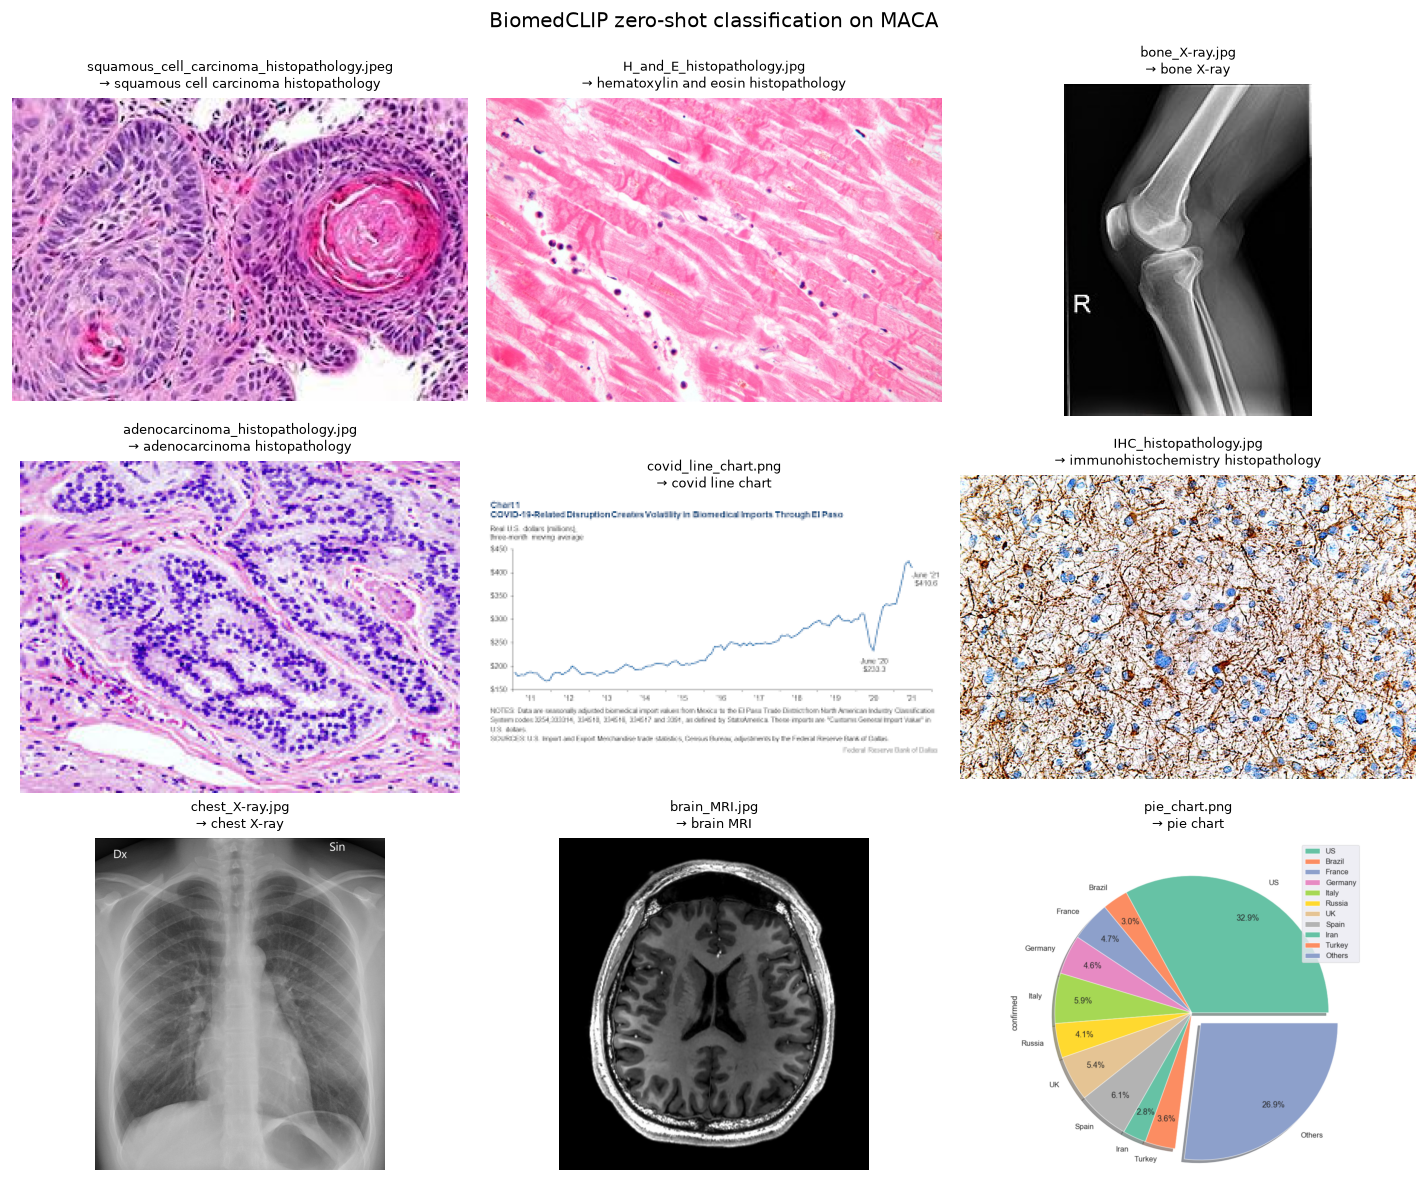

In [3]:
import matplotlib.pyplot as plt

template = "this is a photo of "
image_paths = [INPUT_DIR / name for name in IMAGE_NAMES]
images = [Image.open(path).convert("RGB") for path in image_paths]
image_batch = torch.stack([preprocess(image) for image in images]).to(DEVICE)
text_batch = tokenizer([template + label for label in LABELS], context_length=CONTEXT_LENGTH).to(DEVICE)
with torch.inference_mode():
    image_features, text_features, logit_scale = model(image_batch, text_batch)
    probabilities = (logit_scale * image_features @ text_features.T).softmax(dim=-1)
probabilities_cpu = probabilities.float().cpu()
sorted_indices = probabilities_cpu.argsort(dim=-1, descending=True)
classification_results = []
for row, name in enumerate(IMAGE_NAMES):
    ranking = [
        {"label": LABELS[int(index)], "probability": float(probabilities_cpu[row, index])}
        for index in sorted_indices[row]
    ]
    classification_results.append({"image": name, "sha256": sha256(image_paths[row]), "top1": ranking[0], "ranking": ranking})
classification_payload = {
    "task": "zero_shot_image_classification",
    "template": template,
    "labels": LABELS,
    "images": classification_results,
    "device": torch.cuda.get_device_name(DEVICE),
}
classification_path = OUTPUT_DIR / "zero_shot_classification.json"
classification_path.write_text(json.dumps(classification_payload, ensure_ascii=False, indent=2), encoding="utf-8")
for result in classification_results:
    print(f"{result['image']}: {result['top1']['label']} ({result['top1']['probability']:.4f})")
print("Saved:", classification_path)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for axis, image, result in zip(axes.flat, images, classification_results):
    axis.imshow(image)
    axis.set_title(f"{result['image']}\n→ {result['top1']['label']}", fontsize=8)
    axis.axis("off")
fig.suptitle("BiomedCLIP zero-shot classification on MACA")
fig.tight_layout()
try:
    display(fig)
except NameError:
    plt.show()
plt.close(fig)

### 2.2 任务二：单张胸部 X 光的图文相似度检索

该单元格使用同一模型和预处理，对模型卡中的 `chest_X-ray.jpg` 与五个候选英文描述计算归一化图文嵌入相似度。它是独立于上一单元的第二个推理任务，结果写入自己的 JSON 文件；相似度排序是工程输出，不是临床判断。

Image: chest_X-ray.jpg
0.4311  a chest X-ray
0.2845  a bone X-ray
0.2091  a histopathology microscopy image
0.1819  a brain MRI
0.1431  a pie chart
Saved: /workspace/tutorial/outputs/image_text_similarity.json


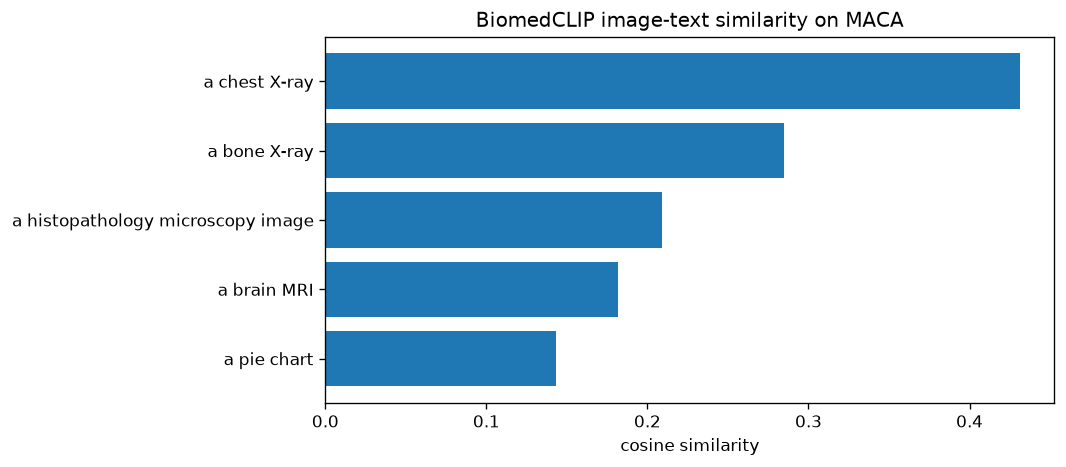

In [4]:
import torch.nn.functional as F

retrieval_image_name = "chest_X-ray.jpg"
retrieval_candidates = [
    "a chest X-ray",
    "a brain MRI",
    "a histopathology microscopy image",
    "a bone X-ray",
    "a pie chart",
]
retrieval_image = Image.open(INPUT_DIR / retrieval_image_name).convert("RGB")
retrieval_tensor = preprocess(retrieval_image).unsqueeze(0).to(DEVICE)
retrieval_text = tokenizer([template + candidate for candidate in retrieval_candidates], context_length=CONTEXT_LENGTH).to(DEVICE)
with torch.inference_mode():
    image_embedding = F.normalize(model.encode_image(retrieval_tensor), dim=-1)
    text_embedding = F.normalize(model.encode_text(retrieval_text), dim=-1)
    similarity = (image_embedding @ text_embedding.T).squeeze(0)
similarity_cpu = similarity.float().cpu()
order = similarity_cpu.argsort(descending=True)
retrieval_results = [
    {"text": retrieval_candidates[int(index)], "similarity": float(similarity_cpu[index])}
    for index in order
]
retrieval_payload = {
    "task": "image_text_similarity_retrieval",
    "image": retrieval_image_name,
    "image_sha256": sha256(INPUT_DIR / retrieval_image_name),
    "candidates": retrieval_results,
    "device": torch.cuda.get_device_name(DEVICE),
}
retrieval_path = OUTPUT_DIR / "image_text_similarity.json"
retrieval_path.write_text(json.dumps(retrieval_payload, ensure_ascii=False, indent=2), encoding="utf-8")
print("Image:", retrieval_image_name)
for result in retrieval_results:
    print(f"{result['similarity']:.4f}  {result['text']}")
print("Saved:", retrieval_path)

fig, axis = plt.subplots(figsize=(9, 4))
axis.barh([result["text"] for result in retrieval_results[::-1]], [result["similarity"] for result in retrieval_results[::-1]])
axis.set_xlabel("cosine similarity")
axis.set_title("BiomedCLIP image-text similarity on MACA")
fig.tight_layout()
try:
    display(fig)
except NameError:
    plt.show()
plt.close(fig)

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以上游官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.